In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [4]:
data=pd.read_csv('datasets/student_clustering.csv')
x=data['cgpa']
y=data['iq']
x,y

(0      5.13
 1      5.90
 2      8.36
 3      8.27
 4      5.45
        ... 
 195    4.68
 196    8.57
 197    5.85
 198    6.23
 199    8.82
 Name: cgpa, Length: 200, dtype: float64,
 0       88
 1      113
 2       93
 3       97
 4      110
       ... 
 195     89
 196    118
 197    112
 198    108
 199    117
 Name: iq, Length: 200, dtype: int64)

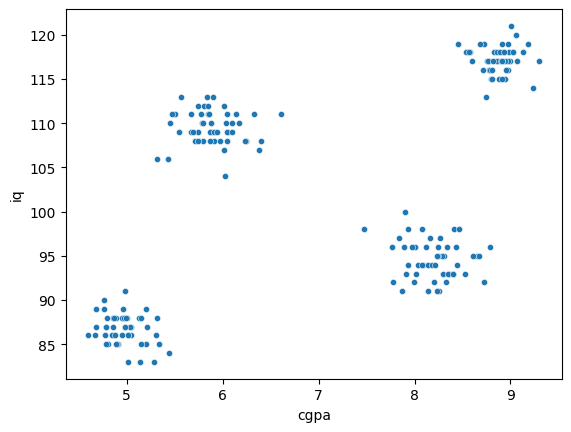

In [5]:
sns.scatterplot(x=x,y=y,s=20)
plt.show()

In [6]:
wcss_dict=dict()
wcss_list=list()
for i in range(1,10):
    m=KMeans(n_clusters=i)
    m.fit(data)
    wcss_dict[f'k={i}']=m.inertia_
    wcss_list.append(m.inertia_)

In [7]:
wcss_dict,wcss_list

({'k=1': 29957.898288000004,
  'k=2': 4184.141270000001,
  'k=3': 2364.005583420084,
  'k=4': 681.9696600000003,
  'k=5': 635.2436960952384,
  'k=6': 528.236345612245,
  'k=7': 357.725165758407,
  'k=8': 282.1793663860056,
  'k=9': 228.74961037240507},
 [29957.898288000004,
  4184.141270000001,
  2364.005583420084,
  681.9696600000003,
  635.2436960952384,
  528.236345612245,
  357.725165758407,
  282.1793663860056,
  228.74961037240507])

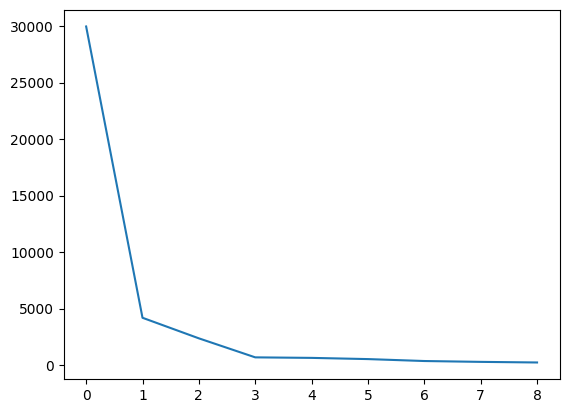

In [8]:
sns.lineplot(x=np.arange(len(wcss_list)),y=wcss_list)
plt.show()

by observing this graph  we can take our no. of clusters k

In [9]:
m1=KMeans(n_clusters=4,random_state=2)
m1.fit(data)
m1.predict(data)

array([3, 0, 1, 1, 0, 0, 1, 2, 0, 1, 3, 0, 1, 3, 0, 1, 0, 1, 0, 0, 1, 3,
       1, 3, 3, 1, 3, 2, 1, 0, 2, 0, 2, 0, 1, 1, 2, 0, 3, 0, 3, 1, 1, 3,
       2, 2, 1, 0, 2, 0, 3, 3, 2, 1, 2, 0, 0, 2, 0, 2, 0, 1, 1, 2, 3, 2,
       1, 3, 0, 1, 0, 2, 1, 3, 0, 2, 0, 2, 3, 1, 1, 2, 0, 3, 2, 3, 2, 0,
       2, 0, 2, 2, 1, 3, 1, 1, 2, 1, 3, 2, 0, 3, 3, 2, 3, 3, 1, 3, 2, 2,
       1, 2, 0, 0, 1, 2, 1, 0, 2, 3, 3, 0, 1, 2, 1, 3, 1, 0, 3, 1, 1, 0,
       3, 3, 0, 2, 0, 3, 1, 1, 1, 3, 0, 3, 3, 2, 3, 2, 0, 3, 2, 3, 2, 2,
       3, 1, 0, 2, 0, 1, 3, 2, 0, 1, 2, 3, 0, 3, 3, 2, 2, 0, 2, 3, 3, 1,
       2, 0, 3, 2, 2, 0, 0, 0, 1, 3, 1, 1, 2, 0, 1, 1, 3, 3, 1, 3, 2, 0,
       0, 2], dtype=int32)

In [10]:
m2=KMeans(n_clusters=4,random_state=2)
y_pred=m2.fit_predict(data)

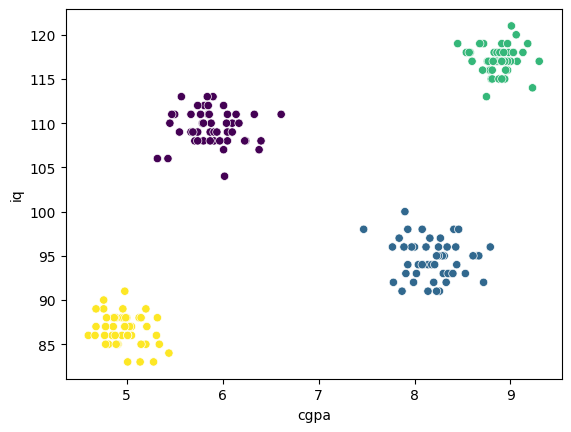

In [11]:
sns.scatterplot(x=data['cgpa'],y=data['iq'],c=y_pred)
plt.show()

In [114]:
x0=data[y_pred==0]
x1=data[y_pred==1]
x2=data[y_pred==2]
x3=data[y_pred==3]

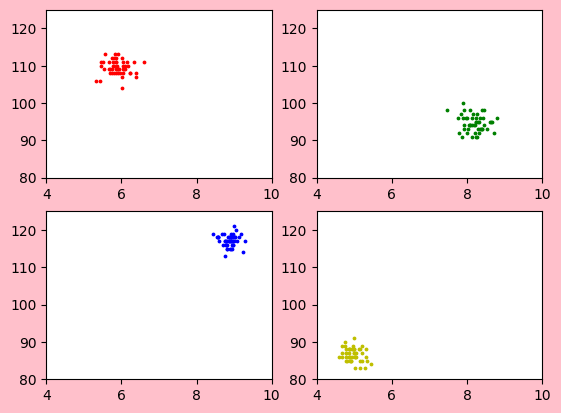

In [133]:
fig,ax=plt.subplots(2,2)
fig.set_facecolor('pink')
for i,j,k,c in zip([x0,x1,x2,x3],[0,0,1,1],[0,1,0,1],list('rgby')):
    ax[j,k].set_xlim(4,10)
    ax[j,k].set_ylim(80,125)
    ax[j,k].scatter(i['cgpa'],i['iq'],s=3,c=c)